In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from f2py_jit import jit

In [18]:
f90 = jit('TSP.f90', flags='-O3 -ffast-math')

# **Prove**
Di seguito alcune prove di consistenza del codice. Vengono proposte 5 regioni generate randomicamente con gli stessi parametri. Ciascuna viene fatta evolvere a temperatura costante per 10 000 MC step. Le temperature sono T=3000 (regime di alta temperatura: protocolli grossolani), T=200 (protocolli grossolani differenziati) e T=1 (regime equiprobabile). 

ncities = 100 perché è un buon numero di paragone con LIBTSP.

In [15]:
# Crea lista di regioni (dizionari)
seed = [246, 897, 531, 306, 969, 212, 721, 545]
ncities = 100
lattice_side = 10000
nregions = 5
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

In [ ]:
nsteps              = 10000
paths               = np.zeros((ncities,nsteps))
lengths             = np.zeros(nsteps)
length_variations   = np.zeros(nsteps)
acceptances         = np.zeros(nsteps)
used_protocols      = np.zeros(nsteps)

In [5]:
# ===== T=3000 =====
temperatures = 3000*np.ones(nsteps)

lengths_3000 = np.zeros((5,nsteps))
stepwise_acceptances_3000 = np.zeros((5,nsteps))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_3000[k,:] = lengths
    stepwise_acceptances_3000[k,:] = stepwise_acceptance_rate

    # Segnala rates protocolli
    print(f'Regione {k+1}, T=3000')
    print(f'    swap:       proposto {protocols_rate[0]:.2f},   accettato {accepted_protocols_rate[0]:.2f}')
    print(f'    transport:  proposto {protocols_rate[1]:.2f},   accettato {accepted_protocols_rate[1]:.2f}')
    print(f'    reverse:    proposto {protocols_rate[2]:.2f},   accettato {accepted_protocols_rate[2]:.2f}')
    print(f'    2-opt:      proposto {protocols_rate[3]:.2f},   accettato {accepted_protocols_rate[3]:.2f}')
    print('')

Regione 1, T=3000
    swap:       proposto 0.50,   accettato 0.50
    transport:  proposto 0.50,   accettato 0.50
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 2, T=3000
    swap:       proposto 0.50,   accettato 0.50
    transport:  proposto 0.50,   accettato 0.50
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 3, T=3000
    swap:       proposto 0.50,   accettato 0.49
    transport:  proposto 0.50,   accettato 0.50
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 4, T=3000
    swap:       proposto 0.50,   accettato 0.50
    transport:  proposto 0.50,   accettato 0.50
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 5, T=3000
    swap:       proposto 0.50,   accettato 0.50
    transport:  proposto 0.50,   accettato 0.50
    reverse:    proposto 0.00,   accettato

In [6]:
# ===== T=200 =====
temperatures = 200*np.ones(nsteps)

lengths_200 = np.zeros((5,nsteps))
stepwise_acceptances_200 = np.zeros((5,nsteps))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_200[k,:] = lengths
    stepwise_acceptances_200[k,:] = stepwise_acceptance_rate

    # Segnala rates protocolli
    print(f'Regione {k+1}, T=200')
    print(f'    swap:       proposto {protocols_rate[0]:.2f},   accettato {accepted_protocols_rate[0]:.2f}')
    print(f'    transport:  proposto {protocols_rate[1]:.2f},   accettato {accepted_protocols_rate[1]:.2f}')
    print(f'    reverse:    proposto {protocols_rate[2]:.2f},   accettato {accepted_protocols_rate[2]:.2f}')
    print(f'    2-opt:      proposto {protocols_rate[3]:.2f},   accettato {accepted_protocols_rate[3]:.2f}')
    print('')

Regione 1, T=200
    swap:       proposto 0.50,   accettato 0.58
    transport:  proposto 0.50,   accettato 0.42
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 2, T=200
    swap:       proposto 0.51,   accettato 0.62
    transport:  proposto 0.49,   accettato 0.37
    reverse:    proposto 0.00,   accettato 0.01
    2-opt:      proposto 0.00,   accettato 0.00

Regione 3, T=200
    swap:       proposto 0.51,   accettato 0.59
    transport:  proposto 0.49,   accettato 0.40
    reverse:    proposto 0.00,   accettato 0.01
    2-opt:      proposto 0.00,   accettato 0.00

Regione 4, T=200
    swap:       proposto 0.50,   accettato 0.65
    transport:  proposto 0.50,   accettato 0.35
    reverse:    proposto 0.00,   accettato 0.00
    2-opt:      proposto 0.00,   accettato 0.00

Regione 5, T=200
    swap:       proposto 0.50,   accettato 0.61
    transport:  proposto 0.49,   accettato 0.38
    reverse:    proposto 0.00,   accettato 0.01

In [7]:
# ===== T=10 =====
temperatures = 10*np.ones(nsteps)

lengths_10 = np.zeros((5,nsteps))
stepwise_acceptances_10 = np.zeros((5,nsteps))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_10[k,:] = lengths
    stepwise_acceptances_10[k,:] = stepwise_acceptance_rate

    # Segnala rates protocolli
    print(f'Regione {k+1}, T=10')
    print(f'    swap:       proposto {protocols_rate[0]:.2f},   accettato {accepted_protocols_rate[0]:.2f}')
    print(f'    transport:  proposto {protocols_rate[1]:.2f},   accettato {accepted_protocols_rate[1]:.2f}')
    print(f'    reverse:    proposto {protocols_rate[2]:.2f},   accettato {accepted_protocols_rate[2]:.2f}')
    print(f'    2-opt:      proposto {protocols_rate[3]:.2f},   accettato {accepted_protocols_rate[3]:.2f}')
    print('')

Regione 1, T=10
    swap:       proposto 0.47,   accettato 0.45
    transport:  proposto 0.47,   accettato 0.29
    reverse:    proposto 0.05,   accettato 0.07
    2-opt:      proposto 0.00,   accettato 0.19

Regione 2, T=10
    swap:       proposto 0.47,   accettato 0.48
    transport:  proposto 0.48,   accettato 0.24
    reverse:    proposto 0.05,   accettato 0.06
    2-opt:      proposto 0.01,   accettato 0.22

Regione 3, T=10
    swap:       proposto 0.48,   accettato 0.46
    transport:  proposto 0.47,   accettato 0.30
    reverse:    proposto 0.04,   accettato 0.07
    2-opt:      proposto 0.00,   accettato 0.17

Regione 4, T=10
    swap:       proposto 0.48,   accettato 0.44
    transport:  proposto 0.47,   accettato 0.32
    reverse:    proposto 0.05,   accettato 0.06
    2-opt:      proposto 0.00,   accettato 0.18

Regione 5, T=10
    swap:       proposto 0.48,   accettato 0.45
    transport:  proposto 0.47,   accettato 0.30
    reverse:    proposto 0.05,   accettato 0.07
    

In [8]:
# ===== T=1 =====
temperatures = 1*np.ones(nsteps)

lengths_1 = np.zeros((5,nsteps))
stepwise_acceptances_1 = np.zeros((5,nsteps))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_1[k,:] = lengths
    stepwise_acceptances_1[k,:] = stepwise_acceptance_rate

    # Segnala rates protocolli
    print(f'Regione {k+1}, T=1')
    print(f'    swap:       proposto {protocols_rate[0]:.2f},   accettato {accepted_protocols_rate[0]:.2f}')
    print(f'    transport:  proposto {protocols_rate[1]:.2f},   accettato {accepted_protocols_rate[1]:.2f}')
    print(f'    reverse:    proposto {protocols_rate[2]:.2f},   accettato {accepted_protocols_rate[2]:.2f}')
    print(f'    2-opt:      proposto {protocols_rate[3]:.2f},   accettato {accepted_protocols_rate[3]:.2f}')
    print('')

Regione 1, T=1
    swap:       proposto 0.32,   accettato 0.09
    transport:  proposto 0.33,   accettato 0.07
    reverse:    proposto 0.33,   accettato 0.11
    2-opt:      proposto 0.02,   accettato 0.74

Regione 2, T=1
    swap:       proposto 0.33,   accettato 0.08
    transport:  proposto 0.32,   accettato 0.07
    reverse:    proposto 0.33,   accettato 0.14
    2-opt:      proposto 0.02,   accettato 0.72

Regione 3, T=1
    swap:       proposto 0.32,   accettato 0.10
    transport:  proposto 0.33,   accettato 0.07
    reverse:    proposto 0.33,   accettato 0.13
    2-opt:      proposto 0.02,   accettato 0.70

Regione 4, T=1
    swap:       proposto 0.32,   accettato 0.07
    transport:  proposto 0.33,   accettato 0.07
    reverse:    proposto 0.33,   accettato 0.13
    2-opt:      proposto 0.02,   accettato 0.72

Regione 5, T=1
    swap:       proposto 0.33,   accettato 0.09
    transport:  proposto 0.33,   accettato 0.08
    reverse:    proposto 0.33,   accettato 0.18
    2-opt

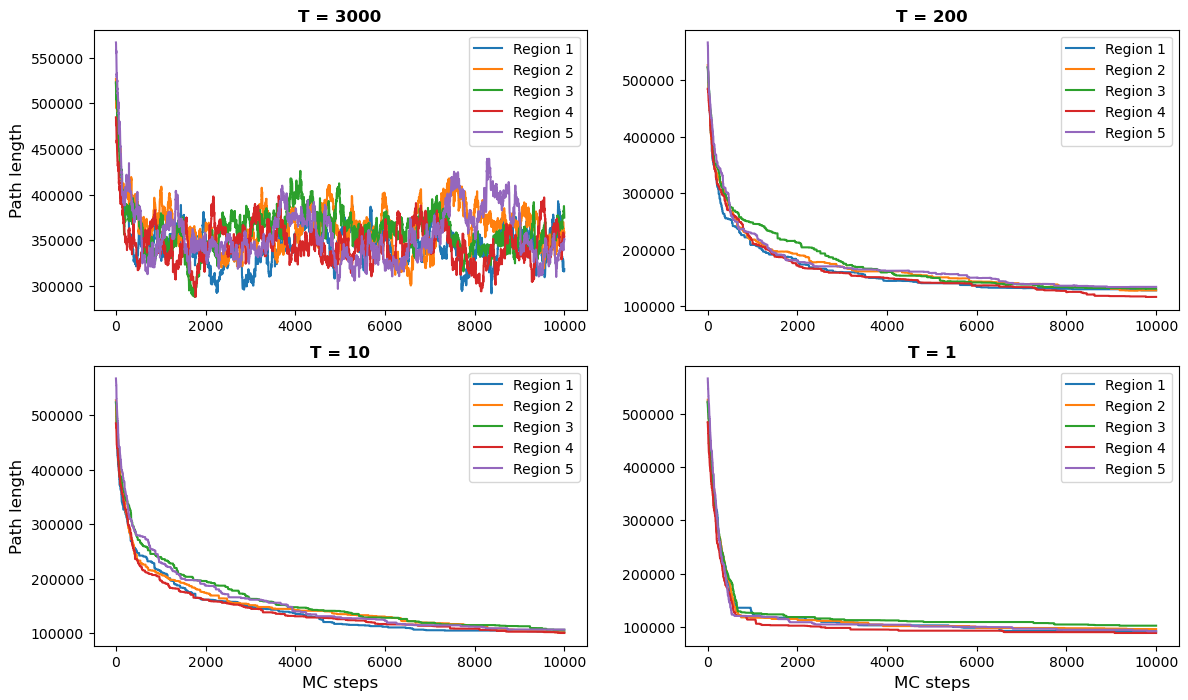

In [15]:
# ===== Plotting =====

fig,ax = plt.subplots(2,2,figsize=(14,8))
ax = ax.flatten()

temp = [3000, 200, 10, 1]   # temperature usate
lengths = [lengths_3000, lengths_200, lengths_10, lengths_1]
accs    = [stepwise_acceptances_3000, stepwise_acceptances_200, stepwise_acceptances_10, stepwise_acceptances_1]

for k in range(len(temp)):
    for j in range(5):
        ax[k].plot(np.arange(nsteps), lengths[k][j], label=f'Region {j+1}')
    ax[k].set_title(f'T = {temp[k]}', fontweight='bold')
    ax[k].legend()

ax[0].set_ylabel('Path length', fontsize=12)
ax[2].set_ylabel('Path length', fontsize=12)

ax[2].set_xlabel('MC steps', fontsize=12)
ax[3].set_xlabel('MC steps', fontsize=12)

plt.savefig('output_images/scan_iniziale.png')
plt.show()

# **Operazioni preliminari**

## **Ricerca della temperatura critica**
La temperatura è in realtà fittizia e si misura in metri (da intendersi come unità arbitraria di lunghezza). Bisogna valutare quali temperature sono da considerarsi "alte" (prevalgono *swap* e *transport*) e quali sono "basse" (prevale *2-opt*).

Si creano 10 array diversi, con 10 città ciascuno e lato 100. Valutiamo le temperature prima grossolanamente, tra 1 e 10000 a passi di 100.

Per ogni temperatura, calcola l'ottimizzazione nelle 20 regioni facendo 10000 passi e raccoglie quali protocolli sono stati usati quante volte. La variazione nell'uso dei protocolli restituirà la temperatura critica.

### **Scan grossolano**

In [16]:
# Temperature
temp_grezze = np.arange(500,10000.1,500)

# Variabili per fortran
ncities = 100
lattice_side = 10000
seed = [123, 456, 789, 987, 654, 321, 306, 200]

# Crea lista di regioni (dizionari)
nregions = 20
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

In [17]:
# Loop su ogni regione per ogni temperatura: acceptance rates e used protocols (sempre mediati sulle regioni create)
                                                    
nsteps              = 10000                         ## 
paths               = np.zeros((ncities,nsteps))    ##
lengths             = np.zeros(nsteps)              ## per 
length_variations   = np.zeros(nsteps)              ## fortran
acceptances         = np.zeros(nsteps)              ##
used_protocols      = np.zeros(nsteps)              ##

rate_swap       = np.zeros(len(temp_grezze))   # rates dei protocolli proposti
rate_transport  = np.zeros(len(temp_grezze))
rate_reverse    = np.zeros(len(temp_grezze))
rate_2opt       = np.zeros(len(temp_grezze))

rate_accepted_swap       = np.zeros(len(temp_grezze))   # rates dei protocolli proposti E accettati
rate_accepted_transport  = np.zeros(len(temp_grezze))
rate_accepted_reverse    = np.zeros(len(temp_grezze))
rate_accepted_2opt       = np.zeros(len(temp_grezze))

rate_acceptance = np.zeros(len(temp_grezze))   # rate di acceptance

for temp_index in range(len(temp_grezze)):   # Per ogni temperatura
    
    temp_rate_swap = 0.0
    temp_rate_transport = 0.0
    temp_rate_reverse = 0.0
    temp_rate_2opt = 0.0
    temp_rate_accepted_swap = 0.0
    temp_rate_accepted_transport = 0.0
    temp_rate_accepted_reverse = 0.0
    temp_rate_accepted_2opt = 0.0
    temp_rate_acceptance = 0.0
    
    for k in range(nregions):   # Per ogni regione

        # Prepara input
        temperatures = temp_grezze[temp_index] * np.ones(nsteps)
        distance_matrix = regions[k]['distance_matrix']
        initial_path = regions[k]['cities_index']
        cities_coords = regions[k]['cities_coords']
        
        # Run
        (paths, lengths, length_variations, acceptances, 
         total_acceptance_rate, stepwise_acceptance_rate, 
         used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
            cities_coords, initial_path, 
            distance_matrix, temperatures
        )
        
        # Accumula i risultati
        temp_rate_swap      += protocols_rate[0]
        temp_rate_transport += protocols_rate[1]
        temp_rate_reverse   += protocols_rate[2]
        temp_rate_2opt      += protocols_rate[3]

        temp_rate_accepted_swap         += accepted_protocols_rate[0]
        temp_rate_accepted_transport    += accepted_protocols_rate[1]
        temp_rate_accepted_reverse      += accepted_protocols_rate[2]
        temp_rate_accepted_2opt         += accepted_protocols_rate[3]

        temp_rate_acceptance += total_acceptance_rate
    
    # Calcola medie sulle regioni
    rate_swap[temp_index] = temp_rate_swap / nregions
    rate_transport[temp_index] = temp_rate_transport / nregions
    rate_reverse[temp_index] = temp_rate_reverse / nregions
    rate_2opt[temp_index] = temp_rate_2opt / nregions
    rate_accepted_swap[temp_index] = temp_rate_accepted_swap / nregions
    rate_accepted_transport[temp_index] = temp_rate_accepted_transport / nregions
    rate_accepted_reverse[temp_index] = temp_rate_accepted_reverse / nregions
    rate_accepted_2opt[temp_index] = temp_rate_accepted_2opt / nregions
    rate_acceptance[temp_index] = temp_rate_acceptance / nregions

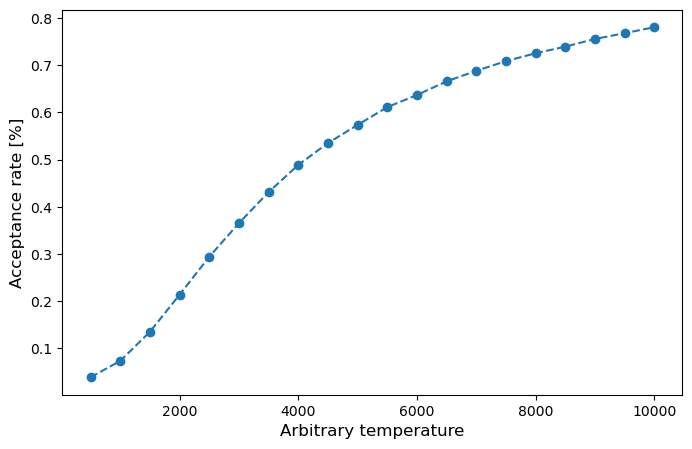

In [38]:
# Plot acceptance rate
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(temp_grezze,rate_acceptance, 'o--',)
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Acceptance rate [%]', fontsize=12)

plt.savefig('output_images/prel_accRate_grosso.png')
plt.show()

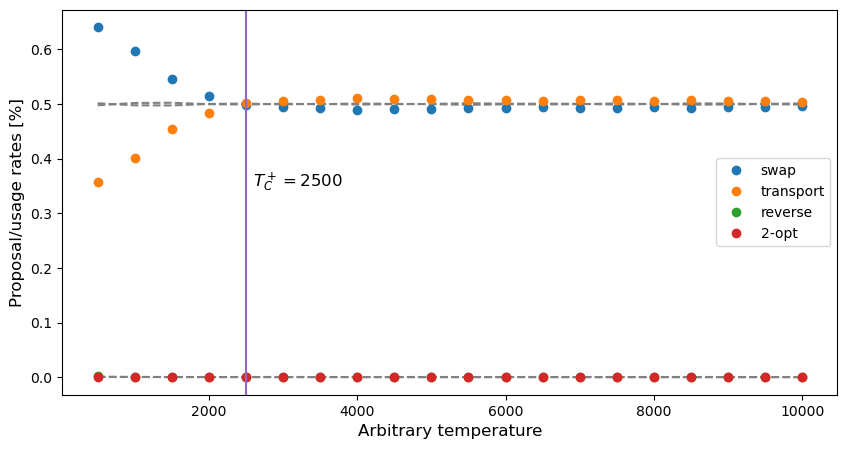

In [ ]:
# Plot protocol rates
fig,ax = plt.subplots(figsize=(8,5))

ax.plot(temp_grezze,rate_swap, '--', c='grey')
ax.plot(temp_grezze,rate_transport,'--',  c='grey')
ax.plot(temp_grezze,rate_reverse,'--', c='grey')
ax.plot(temp_grezze,rate_2opt,'--', c='grey')

ax.plot(temp_grezze,rate_accepted_swap, 'o', label='swap')
ax.plot(temp_grezze,rate_accepted_transport,'o', label='transport')
ax.plot(temp_grezze,rate_accepted_reverse,'o', label='reverse')
ax.plot(temp_grezze,rate_accepted_2opt,'o', label='2-opt')

ax.axvline(2500, c='C4')
ax.text(2600,0.35,r'$T_C^+ = 2500$', fontsize=12)

ax.legend()
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Proposal/usage rates [%]', fontsize=12)

plt.savefig('output_images/prel_scangrosso.png')
plt.show()

### **Scan fine**

In [39]:
# Temperature
temp_fini = np.arange(100,2500.1,100)

# Variabili per fortran
ncities = 100
lattice_side = 10000
seed = [123, 456, 789, 987, 654, 321, 306, 200]

# Crea lista di regioni (dizionari)
nregions = 20
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

In [40]:
# Loop su ogni regione per ogni temperatura: acceptance rates e used protocols (sempre mediati sulle regioni create)
                                                    
nsteps              = 10000                         ## 
paths               = np.zeros((ncities,nsteps))    ##
lengths             = np.zeros(nsteps)              ## per 
length_variations   = np.zeros(nsteps)              ## fortran
acceptances         = np.zeros(nsteps)              ##
used_protocols      = np.zeros(nsteps)              ##

rate_swap       = np.zeros(len(temp_fini))   # rates dei protocolli proposti
rate_transport  = np.zeros(len(temp_fini))
rate_reverse    = np.zeros(len(temp_fini))
rate_2opt       = np.zeros(len(temp_fini))

rate_accepted_swap       = np.zeros(len(temp_fini))   # rates dei protocolli proposti E accettati
rate_accepted_transport  = np.zeros(len(temp_fini))
rate_accepted_reverse    = np.zeros(len(temp_fini))
rate_accepted_2opt       = np.zeros(len(temp_fini))

rate_acceptance = np.zeros(len(temp_fini))   # rate di acceptance

for temp_index in range(len(temp_fini)):   # Per ogni temperatura
    
    temp_rate_swap = 0.0
    temp_rate_transport = 0.0
    temp_rate_reverse = 0.0
    temp_rate_2opt = 0.0
    temp_rate_accepted_swap = 0.0
    temp_rate_accepted_transport = 0.0
    temp_rate_accepted_reverse = 0.0
    temp_rate_accepted_2opt = 0.0
    temp_rate_acceptance = 0.0
    
    for k in range(nregions):   # Per ogni regione

        # Prepara input
        temperatures = temp_fini[temp_index] * np.ones(nsteps)
        distance_matrix = regions[k]['distance_matrix']
        initial_path = regions[k]['cities_index']
        cities_coords = regions[k]['cities_coords']
        
        # Run
        (paths, lengths, length_variations, acceptances, 
         total_acceptance_rate, stepwise_acceptance_rate, 
         used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
            cities_coords, initial_path, 
            distance_matrix, temperatures
        )
        
        # Accumula i risultati
        temp_rate_swap      += protocols_rate[0]
        temp_rate_transport += protocols_rate[1]
        temp_rate_reverse   += protocols_rate[2]
        temp_rate_2opt      += protocols_rate[3]

        temp_rate_accepted_swap         += accepted_protocols_rate[0]
        temp_rate_accepted_transport    += accepted_protocols_rate[1]
        temp_rate_accepted_reverse      += accepted_protocols_rate[2]
        temp_rate_accepted_2opt         += accepted_protocols_rate[3]

        temp_rate_acceptance += total_acceptance_rate
    
    # Calcola medie sulle regioni
    rate_swap[temp_index] = temp_rate_swap / nregions
    rate_transport[temp_index] = temp_rate_transport / nregions
    rate_reverse[temp_index] = temp_rate_reverse / nregions
    rate_2opt[temp_index] = temp_rate_2opt / nregions
    rate_accepted_swap[temp_index] = temp_rate_accepted_swap / nregions
    rate_accepted_transport[temp_index] = temp_rate_accepted_transport / nregions
    rate_accepted_reverse[temp_index] = temp_rate_accepted_reverse / nregions
    rate_accepted_2opt[temp_index] = temp_rate_accepted_2opt / nregions
    rate_acceptance[temp_index] = temp_rate_acceptance / nregions

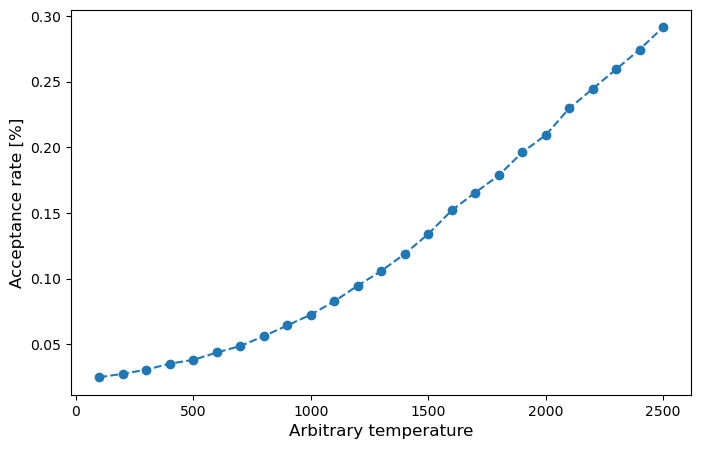

In [41]:
# Plot acceptance rate
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(temp_fini,rate_acceptance, 'o--',)
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Acceptance rate [%]', fontsize=12)

plt.savefig('output_images/prel_accRate_fine.png')
plt.show()

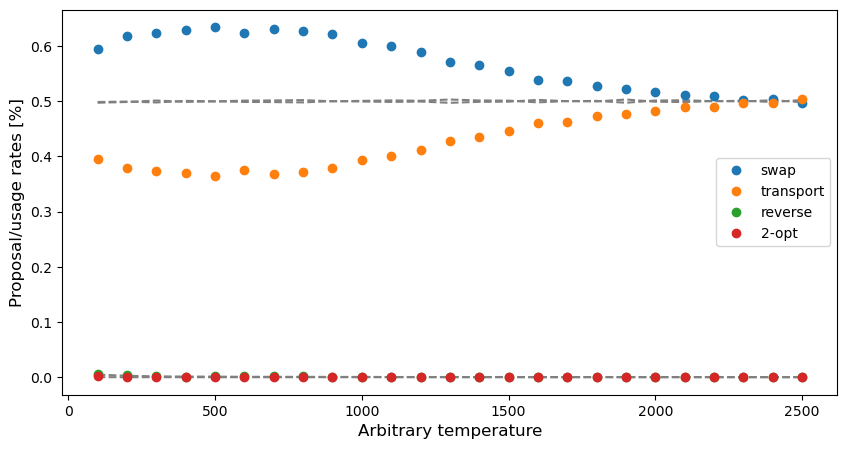

In [ ]:
# Plot protocol rates
fig,ax = plt.subplots(figsize=(8,5))

ax.plot(temp_fini,rate_swap, '--', c='grey')
ax.plot(temp_fini,rate_transport,'--',  c='grey')
ax.plot(temp_fini,rate_reverse,'--', c='grey')
ax.plot(temp_fini,rate_2opt,'--', c='grey')

ax.plot(temp_fini,rate_accepted_swap, 'o', label='swap')
ax.plot(temp_fini,rate_accepted_transport,'o', label='transport')
ax.plot(temp_fini,rate_accepted_reverse,'o', label='reverse')
ax.plot(temp_fini,rate_accepted_2opt,'o', label='2-opt')

ax.legend()
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Proposal/usage rates [%]', fontsize=12)

plt.savefig('output_images/prel_scanfine.png')
plt.show()

### **Scan finissimo**

In [44]:
# Temperature
temp_finissime = np.arange(1,500.1,1)

# Variabili per fortran
ncities = 100
lattice_side = 10000
seed = [123, 456, 789, 987, 654, 321, 306, 200]

# Crea lista di regioni (dizionari)
nregions = 20
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

In [45]:
# Loop su ogni regione per ogni temperatura: acceptance rates e used protocols (sempre mediati sulle regioni create)
                                                    
nsteps              = 10000                         ## 
paths               = np.zeros((ncities,nsteps))    ##
lengths             = np.zeros(nsteps)              ## per 
length_variations   = np.zeros(nsteps)              ## fortran
acceptances         = np.zeros(nsteps)              ##
used_protocols      = np.zeros(nsteps)              ##

rate_swap       = np.zeros(len(temp_finissime))   # rates dei protocolli proposti
rate_transport  = np.zeros(len(temp_finissime))
rate_reverse    = np.zeros(len(temp_finissime))
rate_2opt       = np.zeros(len(temp_finissime))

rate_accepted_swap       = np.zeros(len(temp_finissime))   # rates dei protocolli proposti E accettati
rate_accepted_transport  = np.zeros(len(temp_finissime))
rate_accepted_reverse    = np.zeros(len(temp_finissime))
rate_accepted_2opt       = np.zeros(len(temp_finissime))

rate_acceptance = np.zeros(len(temp_finissime))   # rate di acceptance

for temp_index in range(len(temp_finissime)):   # Per ogni temperatura
    
    temp_rate_swap = 0.0
    temp_rate_transport = 0.0
    temp_rate_reverse = 0.0
    temp_rate_2opt = 0.0
    temp_rate_accepted_swap = 0.0
    temp_rate_accepted_transport = 0.0
    temp_rate_accepted_reverse = 0.0
    temp_rate_accepted_2opt = 0.0
    temp_rate_acceptance = 0.0
    
    for k in range(nregions):   # Per ogni regione

        # Prepara input
        temperatures = temp_finissime[temp_index] * np.ones(nsteps)
        distance_matrix = regions[k]['distance_matrix']
        initial_path = regions[k]['cities_index']
        cities_coords = regions[k]['cities_coords']
        
        # Run
        (paths, lengths, length_variations, acceptances, 
         total_acceptance_rate, stepwise_acceptance_rate, 
         used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
            cities_coords, initial_path, 
            distance_matrix, temperatures
        )
        
        # Accumula i risultati
        temp_rate_swap      += protocols_rate[0]
        temp_rate_transport += protocols_rate[1]
        temp_rate_reverse   += protocols_rate[2]
        temp_rate_2opt      += protocols_rate[3]

        temp_rate_accepted_swap         += accepted_protocols_rate[0]
        temp_rate_accepted_transport    += accepted_protocols_rate[1]
        temp_rate_accepted_reverse      += accepted_protocols_rate[2]
        temp_rate_accepted_2opt         += accepted_protocols_rate[3]

        temp_rate_acceptance += total_acceptance_rate
    
    # Calcola medie sulle regioni
    rate_swap[temp_index] = temp_rate_swap / nregions
    rate_transport[temp_index] = temp_rate_transport / nregions
    rate_reverse[temp_index] = temp_rate_reverse / nregions
    rate_2opt[temp_index] = temp_rate_2opt / nregions
    rate_accepted_swap[temp_index] = temp_rate_accepted_swap / nregions
    rate_accepted_transport[temp_index] = temp_rate_accepted_transport / nregions
    rate_accepted_reverse[temp_index] = temp_rate_accepted_reverse / nregions
    rate_accepted_2opt[temp_index] = temp_rate_accepted_2opt / nregions
    rate_acceptance[temp_index] = temp_rate_acceptance / nregions

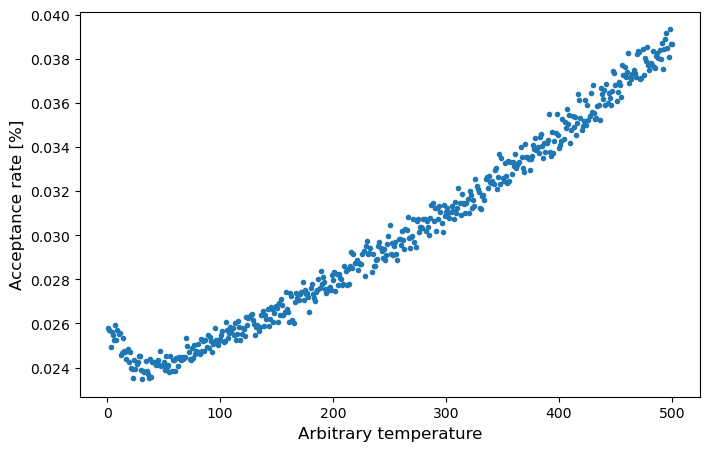

In [49]:
# Plot acceptance rate
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(temp_finissime,rate_acceptance, '.',)
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Acceptance rate [%]', fontsize=12)

plt.savefig('output_images/prel_accRate_finissimo.png')
plt.show()

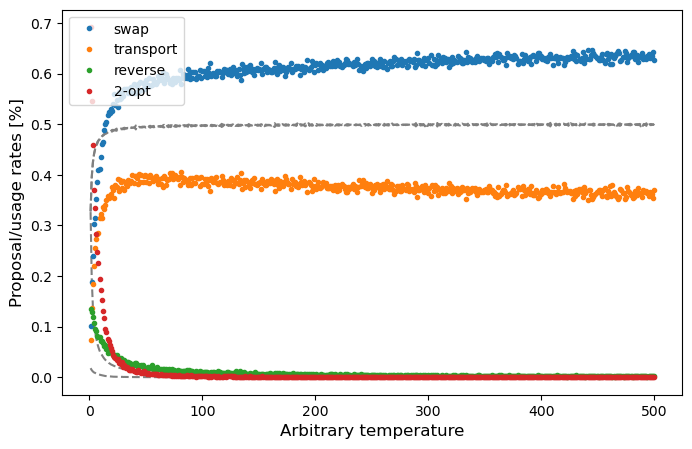

In [50]:
# Plot protocol rates
fig,ax = plt.subplots(figsize=(8,5))

ax.plot(temp_finissime,rate_swap, '--', c='grey')
ax.plot(temp_finissime,rate_transport,'--',  c='grey')
ax.plot(temp_finissime,rate_reverse,'--', c='grey')
ax.plot(temp_finissime,rate_2opt,'--', c='grey')

ax.plot(temp_finissime,rate_accepted_swap, '.', label='swap')
ax.plot(temp_finissime,rate_accepted_transport,'.', label='transport')
ax.plot(temp_finissime,rate_accepted_reverse,'.', label='reverse')
ax.plot(temp_finissime,rate_accepted_2opt,'.', label='2-opt')

ax.legend()
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Proposal/usage rates [%]', fontsize=12)

plt.savefig('output_images/prel_scanfinissimo.png')
plt.show()

### **Scan iperfine**

In [4]:
# Temperature
temp_iperfini = np.arange(0.05,5.001,0.05)

# Variabili per fortran
ncities = 100
lattice_side = 10000
seed = [555, 456, 789, 666, 654, 777, 306, 200]

# Crea lista di regioni (dizionari)
nregions = 20
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

In [5]:
# Loop su ogni regione per ogni temperatura: acceptance rates e used protocols (sempre mediati sulle regioni create)
                                                    
nsteps              = 1000                          ## 
paths               = np.zeros((ncities,nsteps))    ##
lengths             = np.zeros(nsteps)              ## per 
length_variations   = np.zeros(nsteps)              ## fortran
acceptances         = np.zeros(nsteps)              ##
used_protocols      = np.zeros(nsteps)              ##

rate_swap       = np.zeros(len(temp_iperfini))   # rates dei protocolli proposti
rate_transport  = np.zeros(len(temp_iperfini))
rate_reverse    = np.zeros(len(temp_iperfini))
rate_2opt       = np.zeros(len(temp_iperfini))

rate_accepted_swap       = np.zeros(len(temp_iperfini))   # rates dei protocolli proposti E accettati
rate_accepted_transport  = np.zeros(len(temp_iperfini))
rate_accepted_reverse    = np.zeros(len(temp_iperfini))
rate_accepted_2opt       = np.zeros(len(temp_iperfini))

rate_acceptance = np.zeros(len(temp_iperfini))   # rate di acceptance

for temp_index in range(len(temp_iperfini)):   # Per ogni temperatura
    
    print(temp_iperfini[temp_index])
    temp_rate_swap = 0.0
    temp_rate_transport = 0.0
    temp_rate_reverse = 0.0
    temp_rate_2opt = 0.0
    temp_rate_accepted_swap = 0.0
    temp_rate_accepted_transport = 0.0
    temp_rate_accepted_reverse = 0.0
    temp_rate_accepted_2opt = 0.0
    temp_rate_acceptance = 0.0
    
    for k in range(nregions):   # Per ogni regione

        # Prepara input
        temperatures = temp_iperfini[temp_index] * np.ones(nsteps)
        distance_matrix = regions[k]['distance_matrix']
        initial_path = regions[k]['cities_index']
        cities_coords = regions[k]['cities_coords']
        
        # Run
        (paths, lengths, length_variations, acceptances,
         total_acceptance_rate, stepwise_acceptance_rate, 
         used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
            cities_coords, initial_path, 
            distance_matrix, temperatures
        )
        
        # Accumula i risultati
        temp_rate_swap      += protocols_rate[0]
        temp_rate_transport += protocols_rate[1]
        temp_rate_reverse   += protocols_rate[2]
        temp_rate_2opt      += protocols_rate[3]

        temp_rate_accepted_swap         += accepted_protocols_rate[0]
        temp_rate_accepted_transport    += accepted_protocols_rate[1]
        temp_rate_accepted_reverse      += accepted_protocols_rate[2]
        temp_rate_accepted_2opt         += accepted_protocols_rate[3]

        temp_rate_acceptance += total_acceptance_rate
    
    # Calcola medie sulle regioni
    rate_swap[temp_index]       = temp_rate_swap / nregions
    rate_transport[temp_index]  = temp_rate_transport / nregions
    rate_reverse[temp_index]    = temp_rate_reverse / nregions
    rate_2opt[temp_index]       = temp_rate_2opt / nregions

    rate_accepted_swap[temp_index]      = temp_rate_accepted_swap / nregions
    rate_accepted_transport[temp_index] = temp_rate_accepted_transport / nregions
    rate_accepted_reverse[temp_index]   = temp_rate_accepted_reverse / nregions
    rate_accepted_2opt[temp_index]      = temp_rate_accepted_2opt / nregions
    
    rate_acceptance[temp_index] = temp_rate_acceptance / nregions

0.05
0.1
0.15000000000000002
0.2
0.25
0.3
0.35000000000000003
0.4
0.45
0.5
0.55
0.6000000000000001
0.6500000000000001
0.7000000000000001
0.7500000000000001
0.8
0.8500000000000001
0.9000000000000001
0.9500000000000001
1.0
1.05
1.1
1.1500000000000001
1.2000000000000002
1.2500000000000002
1.3
1.35
1.4000000000000001
1.4500000000000002
1.5000000000000002
1.55
1.6
1.6500000000000001
1.7000000000000002
1.7500000000000002
1.8
1.85
1.9000000000000001
1.9500000000000002
2.0
2.05
2.1
2.15
2.1999999999999997
2.25
2.3
2.35
2.4
2.45
2.5
2.55
2.6
2.65
2.7
2.75
2.8
2.85
2.9
2.95
3.0
3.05
3.1
3.15
3.2
3.25
3.3
3.35
3.4
3.45
3.5
3.55
3.6
3.65
3.7
3.75
3.8
3.85
3.9
3.95
4.0
4.05
4.1
4.15
4.2
4.25
4.3
4.35
4.4
4.45
4.5
4.55
4.6
4.65
4.7
4.75
4.8
4.8500000000000005
4.9
4.95
5.0


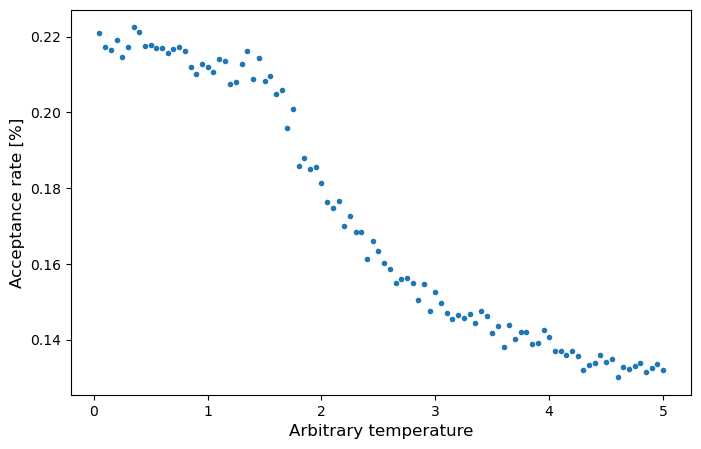

In [6]:
# Plot acceptance rate
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(temp_iperfini,rate_acceptance, '.',)
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Acceptance rate [%]', fontsize=12)

plt.savefig('output_images/prel_accRate_iperfini.png')
plt.show()

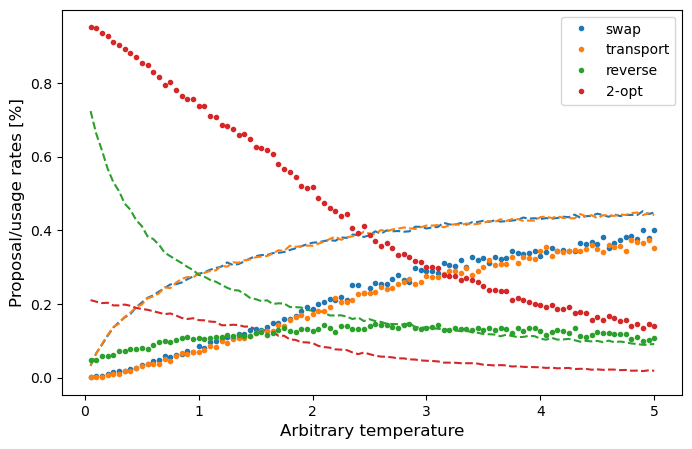

In [9]:
# Plot protocol rates
fig,ax = plt.subplots(figsize=(8,5))

ax.plot(temp_iperfini,rate_swap, '--')
ax.plot(temp_iperfini,rate_transport,'--',)
ax.plot(temp_iperfini,rate_reverse,'--')
ax.plot(temp_iperfini,rate_2opt,'--')

ax.plot(temp_iperfini,rate_accepted_swap, '.', c='C0', label='swap')
ax.plot(temp_iperfini,rate_accepted_transport,'.', c='C1', label='transport')
ax.plot(temp_iperfini,rate_accepted_reverse,'.', c='C2', label='reverse')
ax.plot(temp_iperfini,rate_accepted_2opt,'.', c='C3', label='2-opt')

ax.legend()
ax.set_xlabel('Arbitrary temperature', fontsize=12)
ax.set_ylabel('Proposal/usage rates [%]', fontsize=12)

plt.savefig('output_images/prel_scaniperfine.png')
plt.show()

## **Protocolli di raffreddamento**
Serve valutare quale protocollo di raffreddamento garantisce il raggiungimento della minima lunghezza. I protocolli proposti sono:
- lineare: il sistema si raffredda costantemente
- esponenziale: il sistema si raffredda subito, per poi rimanere più a lungo a basse temperature
- gaussiano: il sistema raffredda poco all'inizio e alla fine
- logaritmico: il sistema rimane ad alta temperatura per molto tempo, e raffredda di colpo alla fine.

Vanno comunque scelte due temperature, di inizio e di fine. I protocolli grossolani si differenziano sotto 2500 gradi, mentre i protocolli fini si differenziano ordini di grandezza più in basso. In particolare, il protocollo 2-opt viene proposto molto più spesso sotto a 1 grado. In generale, quindi, gli ordini di grandezza su cui agire sono 4.

La temperatura iniziale può essere 2000 gradi. Il sistema dovrebbe essere raffreddato fino a temperature prossime allo zero: 0.01 può andare. Vista la pendenza ripida del proposal rate dei protocolli fini vicino allo zero, ci aspettiamo che funzionino meglio i protocolli che tengono il sistema a lungo "al fresco".

In [18]:
# Gaussiana con decrescita "sharp" (dettata da 'exp')

def custom_gaussian(x, mean, sigma, exp):
    z = exp * np.log(np.abs(x-mean)) - np.log(2) - exp*np.log(sigma)
    return np.exp(-np.exp(z))

In [43]:
nsteps = 10000
T0 = 2000
Tf = 0.01
xvec = np.arange(1,nsteps+1)

# Protocollo lineare
temp_linear = np.linspace(T0, Tf, nsteps)

# Protocollo "geometrico"
temp_geom = np.geomspace(T0, Tf, nsteps)

# Protocollo "antigeometrico"
temp_antigeom = T0 - np.geomspace(T0, Tf, nsteps)[::-1]

# Protocollo gaussiano (exp=5
temp_gauss_5 = T0*custom_gaussian(xvec, 0, nsteps/2, 5) + Tf

*NB aggiungere altri protocolli gaussiani all'occorrenza, con exp=6,7,8,9,10... (mai sotto 5 perché sennò non va sotto T=1 con la sigma imposta).*

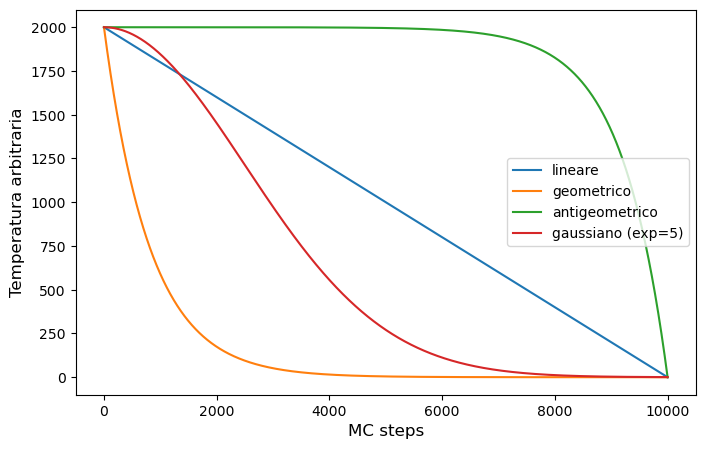

In [ ]:
fig,ax = plt.subplots(figsize=(8,5))

ax.plot(xvec, temp_linear, label='lineare')
ax.plot(xvec, temp_geom, label='geometrico')
ax.plot(xvec, temp_antigeom, label='antigeometrico')
ax.plot(xvec, temp_gauss_5, label='gaussiano (exp=5)')
ax.legend()
ax.set_xlabel('MC steps', fontsize=12)
ax.set_ylabel('Temperatura arbitraria', fontsize=12)

plt.savefig('output_images/panoramica_raffreddamento.png')
plt.show()

In [21]:
# Crea lista di regioni come nella prova iniziale

seed = [246, 897, 531, 306, 969, 212, 721, 545]
ncities = 100
lattice_side = 10000
nregions = 5
regions = []
for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

### **Raffreddamento lineare**

In [22]:
nsteps = 100000
lengths_plot = np.zeros((5,nsteps))
T0 = 2000
Tf = 0.01

temp_linear = np.linspace(T0, Tf, nsteps)

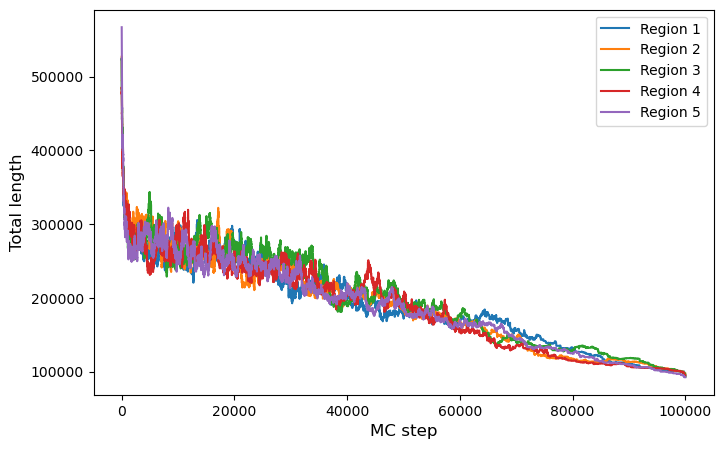

In [25]:
temperatures = temp_linear
fig,ax = plt.subplots(figsize=(8,5))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_plot[k,:] = lengths

    # Plotta
    ax.plot(np.arange(nsteps), lengths_plot[k,:], label=f'Region {k+1}')

ax.legend()
ax.set_xlabel('MC step', fontsize=12)
ax.set_ylabel('Total length', fontsize=12)

plt.savefig('output_images/raff_lineare.png')
plt.show()

### **Raffreddamento geometrico**

In [26]:
nsteps = 100000
lengths_plot = np.zeros((5,nsteps))
T0 = 2000
Tf = 0.01

temp_geom = np.geomspace(T0, Tf, nsteps)

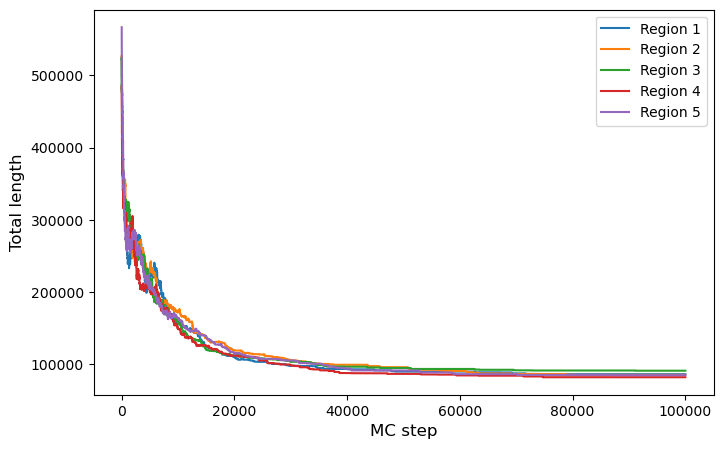

In [28]:
temperatures = temp_geom
fig,ax = plt.subplots(figsize=(8,5))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_plot[k,:] = lengths

    # Plotta
    ax.plot(np.arange(nsteps), lengths_plot[k,:], label=f'Region {k+1}')

ax.legend()
ax.set_xlabel('MC step', fontsize=12)
ax.set_ylabel('Total length', fontsize=12)

plt.savefig('output_images/raff_geometrico.png')
plt.show()

### **Raffreddamento antigeometrico**

In [29]:
nsteps = 100000
lengths_plot = np.zeros((5,nsteps))
T0 = 2000
Tf = 0.01

temp_antigeom = T0 - np.geomspace(T0, Tf, nsteps)[::-1]

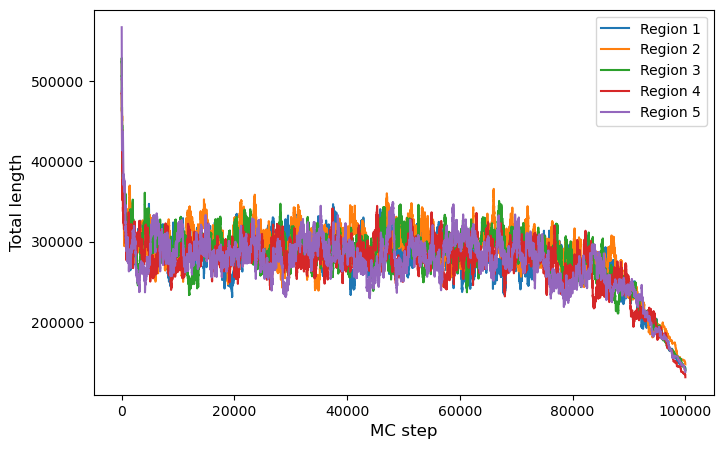

In [30]:
temperatures = temp_antigeom
fig,ax = plt.subplots(figsize=(8,5))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_plot[k,:] = lengths

    # Plotta
    ax.plot(np.arange(nsteps), lengths_plot[k,:], label=f'Region {k+1}')

ax.legend()
ax.set_xlabel('MC step', fontsize=12)
ax.set_ylabel('Total length', fontsize=12)

plt.savefig('output_images/raff_antigeometrico.png')
plt.show()

### **Raffreddamento gaussiano**

In [41]:
nsteps = 100000
lengths_plot = np.zeros((5,nsteps))
T0 = 2000
Tf = 0.01

temp_gauss_5 = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/4, 2) + Tf

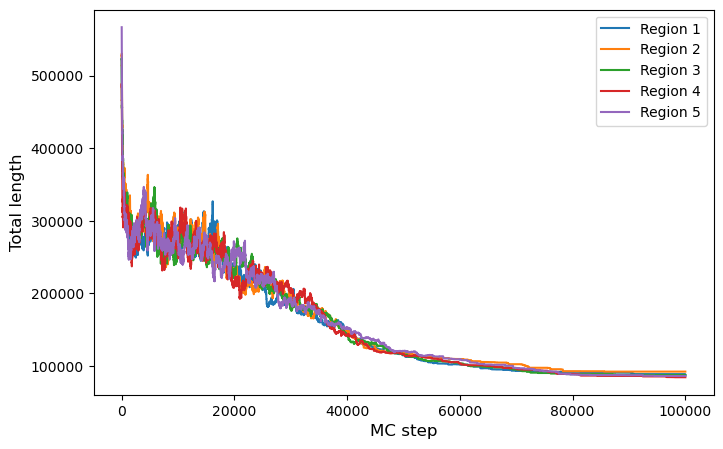

In [42]:
temperatures = temp_gauss_5
fig,ax = plt.subplots(figsize=(8,5))

for k in range(nregions):   # Per ogni regione

    distance_matrix = regions[k]['distance_matrix']
    initial_path = regions[k]['cities_index']
    cities_coords = regions[k]['cities_coords']
    
    # Run
    (paths, lengths, length_variations, acceptances, 
        total_acceptance_rate, stepwise_acceptance_rate, 
        used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
        cities_coords, initial_path, 
        distance_matrix, temperatures
    )

    # Accumula vettori per plot
    lengths_plot[k,:] = lengths

    # Plotta
    ax.plot(np.arange(nsteps), lengths_plot[k,:], label=f'Region {k+1}')

ax.legend()
ax.set_xlabel('MC step', fontsize=12)
ax.set_ylabel('Total length', fontsize=12)

plt.savefig('output_images/raff_gaussiano.png')
plt.show()

Il raffreddamento lineare sembra dare buoni risultati, anche se non sensibilmente migliori delle prove fatte a temperatura costante. Sorprendentemente, anche il protocollo geometrico, che raffredda rapidamente il sistema all'inizio e lo lascia a lungo a basse temperature, restituisce dei risultati non sensibilmente peggiori dalla performance del protocollo lineare. Il protocollo antigeometrico, come da aspettarsi, non lascia al sistema tempo sufficiente per esplorare un minimo locale sufficientemente profondo.

Tra tutti, il protocollo più promettente sembra essere quello gaussiano, perché unisce la termalizzazione garantita a temperatura costante con la decrescita graduale e marcata dei protocolli con più successo. Sarebbe opportuno esplorare più possibilità: una decrescita meno marcata garantirebbe una più ampia ricerca di un minimo più favorevole, e diminuire la varianza lascia evolvere il sistema in un regime più favorevole, dato che ad alte temperature il sistema satura subito la lunghezza più breve che può raggiungere.

## **Protocollo gaussiano: nuove prove**


In [35]:
def custom_gaussian(x, mean, sigma, exp):
    z = exp * np.log(np.abs(x-mean)) - np.log(2) - exp*np.log(sigma)
    return np.exp(-np.exp(z))

In [36]:
# Crea lista di regioni come nella prova iniziale

seed = [246, 897, 531, 306, 969, 212, 721, 545]
ncities = 100
lattice_side = 10000
nregions = 5
regions = []

for k in range(nregions):
    # Aggiorna seed
    seed = [s+k*123 for s in seed]
    # Crea dizionario k-esima regione
    cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)
    regions.append(dict(cities_index=cities_index, cities_coords=cities_coords, distance_matrix=distance_matrix))

Esp.: 2, sigma: nsteps/3, regione 1
Lunghezza iniziale: 522649.41
Lunghezza finale: 83892.57
Min lunghezza: 83874.17
Acceptance rate: 0.066

Esp.: 2, sigma: nsteps/3, regione 2
Lunghezza iniziale: 526830.18
Lunghezza finale: 87485.67
Min lunghezza: 87485.67
Acceptance rate: 0.060

Esp.: 2, sigma: nsteps/3, regione 3
Lunghezza iniziale: 523094.89
Lunghezza finale: 87450.10
Min lunghezza: 87450.10
Acceptance rate: 0.066

Esp.: 2, sigma: nsteps/3, regione 4
Lunghezza iniziale: 484728.24
Lunghezza finale: 84128.40
Min lunghezza: 84117.91
Acceptance rate: 0.074

Esp.: 2, sigma: nsteps/3, regione 5
Lunghezza iniziale: 566831.61
Lunghezza finale: 88493.69
Min lunghezza: 88493.69
Acceptance rate: 0.062

Esp.: 2, sigma: nsteps/4, regione 1
Lunghezza iniziale: 522649.41
Lunghezza finale: 82378.73
Min lunghezza: 82378.73
Acceptance rate: 0.052

Esp.: 2, sigma: nsteps/4, regione 2
Lunghezza iniziale: 526830.18
Lunghezza finale: 86125.67
Min lunghezza: 86125.67
Acceptance rate: 0.047

Esp.: 2, sigm

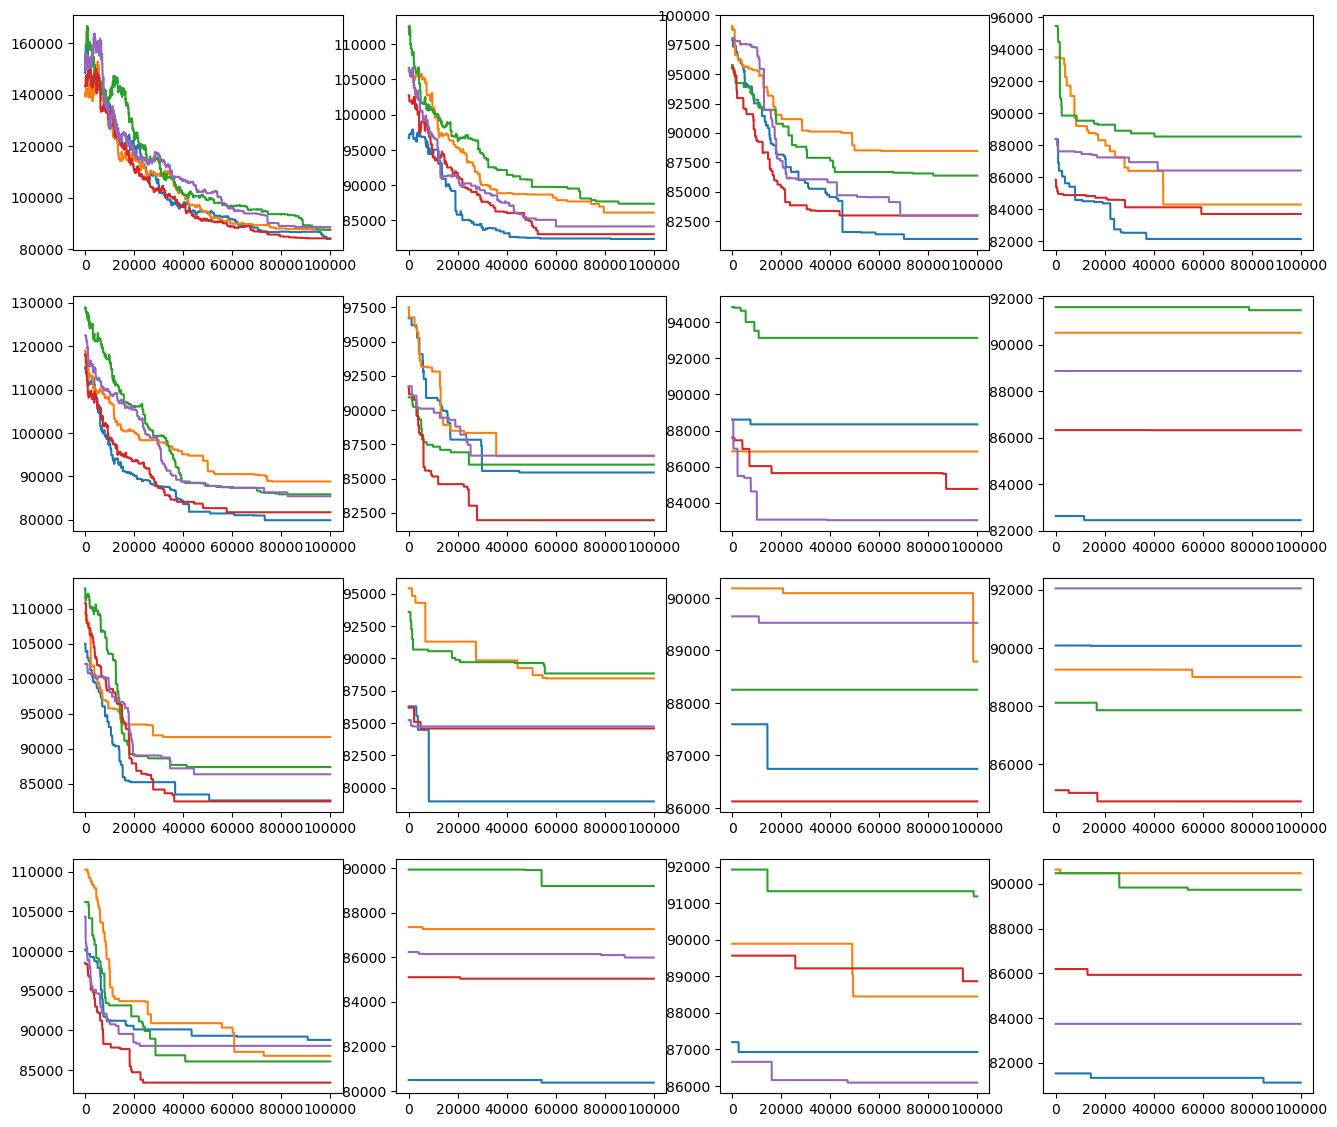

In [20]:
nsteps = 200000
xvec = np.arange(1,nsteps)
T0 = 2000
Tf = 0.01

exponents = [2,3,4,5]
sigmas = [3,4,5,6]

fig,ax = plt.subplots(len(exponents), len(sigmas), figsize=(16,14))
lengths_plot = np.zeros((len(exponents), len(sigmas), len(regions), nsteps))

for k in range(len(exponents)):
    for j in range(len(sigmas)):

            temperatures = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/sigmas[j], exponents[k]) + Tf

            for r in range(len(regions)):

                # (estrae regioni)
                distance_matrix = regions[r]['distance_matrix']
                initial_path = regions[r]['cities_index']
                cities_coords = regions[r]['cities_coords']

                # (lancia metropolis_run)
                (paths, lengths, length_variations, acceptances, 
                    total_acceptance_rate, stepwise_acceptance_rate, 
                    used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
                    cities_coords, initial_path, 
                    distance_matrix, temperatures
                )

                # (raccoglie e plotta)
                print(f"Esp.: {exponents[k]}, sigma: nsteps/{sigmas[j]}, regione {r+1}")
                print(f"Lunghezza iniziale: {lengths[0]:.2f}")
                print(f"Lunghezza finale: {lengths[-1]:.2f}")
                print(f"Min lunghezza: {lengths.min():.2f}")
                print(f"Acceptance rate: {total_acceptance_rate:.3f}")
                print("")
                lengths_plot[k,j,r,:] = lengths
                ax[k,j].plot(lengths_plot[k,j,r,100000:], label=f'Region {r+1}')

            np.save(f'gaussian_exp{exponents[k]}_divSigma{sigmas[j]}.npy', lengths_plot[k,j,:,:])

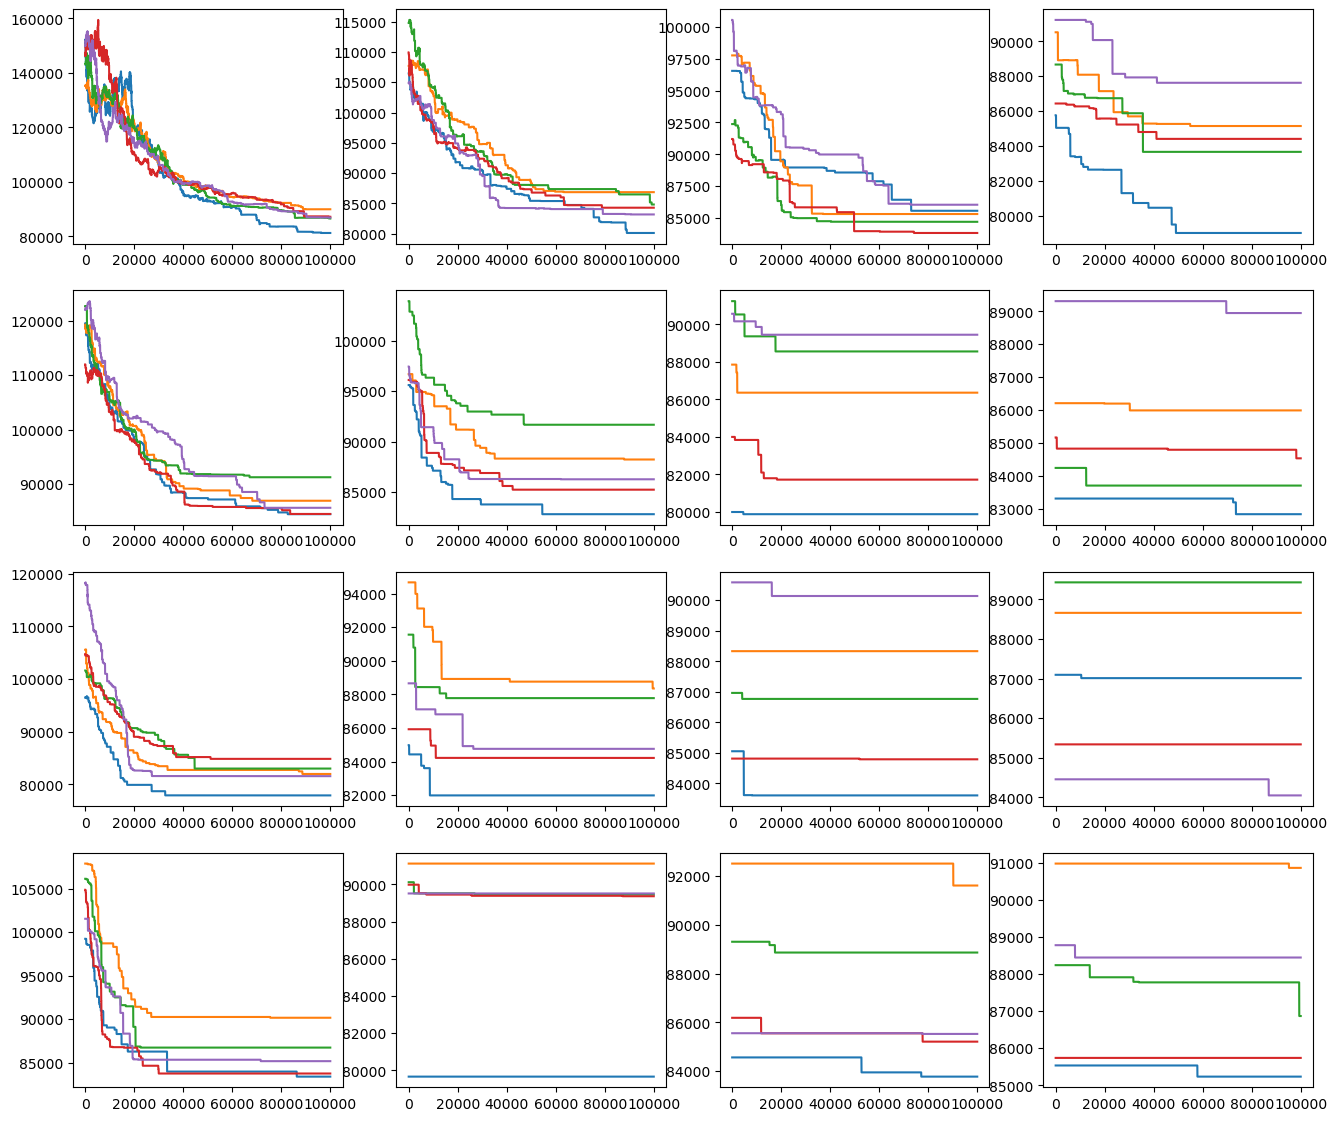

In [11]:
fig,ax = plt.subplots(len(exponents), len(sigmas), figsize=(16,14))
for k in range(len(exponents)):
    for j in range(len(sigmas)):
        for r in range(len(regions)):
            ax[k,j].plot(lengths_plot[k,j,r,100000:], label=f'Region {r+1}')
            #ax[k,j].set_ylim([80000,90000])

# **Calcolo effettivo**
Chiaramente il regime migliore si ha con una temperatura che diminuisce come una gaussiana dove $\sigma=\sigma/5$. Allora, con questo protocollo di raffreddamento, applichiamo la routine in TSP.f90 ad alcuni esempi di libreria. Per esigenze di hardware, ogni simulazione sarà di 200mila step.

Per ognuno dei .tsp, il seed viene cambiato 20 (50?) volte e poi si media. Volendo, si può fare un grafico in funzione del numero di città per valutare la performance.

In [ ]:
def custom_gaussian(x, mean, sigma, exp):
    z = exp * np.log(np.abs(x-mean)) - np.log(2) - exp*np.log(sigma)
    return np.exp(-np.exp(z))
    
nsteps = 200000
T0 = 2000
Tf = 0.01
temperatures_raw = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/5, 2) + Tf
temperatures = np.asarray(temperatures_raw, dtype=np.float64, order='F')   # a scanso di equivoci

**NB** - Cambiando nsteps a 300mila non ci sono differenze sostanziali! La lunghezza rimane uguale o diminuisce pochissimo. Aumentando nsteps anche il protocollo di raffreddamento viene "stirato": il sistema, fra il resto, spende più tempo nel transiente caldo iniziale. Quindi vuol dire che è già sufficiente a 200mila!

In [5]:
# Funzione per leggere files TSPLIB-like

def read_tsplib(filename):
    """
    Legge un file TSPLIB e restituisce dati nel formato per Fortran.
    """
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Inizializza
    ncities = 0
    coords_start = 0
    edge_weight_type = 'EUC_2D'
    edge_weight_format = None
    name = ''
    distance_matrix = None  # <-- AGGIUNGI QUESTA RIGA
    
    for i, line in enumerate(lines):
        line = line.strip()
        if line.startswith('NAME'):
            name = line.split(':')[1].strip()
        elif line.startswith('DIMENSION'):
            ncities = int(line.split(':')[1].strip())
        elif line.startswith('EDGE_WEIGHT_TYPE'):
            edge_weight_type = line.split(':')[1].strip()
        elif line.startswith('EDGE_WEIGHT_FORMAT'):
            edge_weight_format = line.split(':')[1].strip()
        elif line.startswith('NODE_COORD_SECTION'):
            coords_start = i + 1
            break
        elif line.startswith('EDGE_WEIGHT_SECTION'):
            # Per file con matrice esplicita
            coords_start = i + 1
            break
    
    # Inizializza array
    coords_x = np.zeros(ncities, dtype=np.float64)
    coords_y = np.zeros(ncities, dtype=np.float64)
    
    # Lettura coordinate basata sul tipo
    if edge_weight_type in ['EUC_2D', 'GEO', 'ATT']:
        # Formato con coordinate (node_id x y)
        for i in range(ncities):
            line = lines[coords_start + i].strip()
            if line == 'EOF' or line == '':
                break
            
            parts = line.split()
            
            # Salta se la riga non ha abbastanza elementi
            if len(parts) < 3:
                continue
            
            # Primo elemento: ID città
            try:
                node_id = int(parts[0])
                coords_x[i] = float(parts[1])
                coords_y[i] = float(parts[2])
            except (ValueError, IndexError) as e:
                print(f"Errore alla riga {coords_start + i}: {line}")
                print(f"Parts: {parts}")
                raise e
    
    elif edge_weight_type == 'EXPLICIT':
        # Leggi la matrice delle distanze direttamente
        print(f"File {name} usa EDGE_WEIGHT_TYPE: EXPLICIT")
        print(f"Formato matrice: {edge_weight_format}")
        
        distance_matrix = np.zeros((ncities, ncities), dtype=np.float64, order='F')
        
        # Leggi tutti i valori dalla sezione EDGE_WEIGHT_SECTION
        values = []
        for i in range(coords_start, len(lines)):
            line = lines[i].strip()
            if line == 'EOF' or line == '':
                break
            if line.startswith('DISPLAY_DATA_SECTION') or line.startswith('NODE_COORD_SECTION'):
                break
            
            parts = line.split()
            for part in parts:
                try:
                    values.append(float(part))
                except ValueError:
                    continue
        
        # Riempimento della matrice in base al formato
        if edge_weight_format == 'FULL_MATRIX':
            # Matrice completa
            idx = 0
            for i in range(ncities):
                for j in range(ncities):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'UPPER_ROW':
            # Triangolare superiore per righe (senza diagonale)
            idx = 0
            for i in range(ncities):
                distance_matrix[i, i] = 0.0
                for j in range(i+1, ncities):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'LOWER_ROW':
            # Triangolare inferiore per righe (senza diagonale)
            idx = 0
            for i in range(ncities):
                for j in range(i):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
                distance_matrix[i, i] = 0.0
        
        elif edge_weight_format == 'UPPER_DIAG_ROW':
            # Triangolare superiore per righe (con diagonale)
            idx = 0
            for i in range(ncities):
                for j in range(i, ncities):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'LOWER_DIAG_ROW':
            # Triangolare inferiore per righe (con diagonale)
            idx = 0
            for i in range(ncities):
                for j in range(i+1):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'UPPER_COL':
            # Triangolare superiore per colonne (senza diagonale)
            idx = 0
            for j in range(ncities):
                distance_matrix[j, j] = 0.0
                for i in range(j):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'LOWER_COL':
            # Triangolare inferiore per colonne (senza diagonale)
            idx = 0
            for j in range(ncities):
                for i in range(j+1, ncities):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
                distance_matrix[j, j] = 0.0
        
        elif edge_weight_format == 'UPPER_DIAG_COL':
            # Triangolare superiore per colonne (con diagonale)
            idx = 0
            for j in range(ncities):
                for i in range(j+1):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        elif edge_weight_format == 'LOWER_DIAG_COL':
            # Triangolare inferiore per colonne (con diagonale)
            idx = 0
            for j in range(ncities):
                for i in range(j, ncities):
                    if idx < len(values):
                        distance_matrix[i, j] = values[idx]
                        distance_matrix[j, i] = values[idx]
                        idx += 1
        
        else:
            print(f"Formato matrice '{edge_weight_format}' non riconosciuto!")
        
        # Per EXPLICIT, le coordinate sono fittizie. Crea coordinate fittizie per compatibilità con il codice (che richiede 'path')
        print("Creazione coordinate fittizie per visualizzazione...")
        grid_size = int(np.ceil(np.sqrt(ncities)))
        for i in range(ncities):
            coords_x[i] = (i % grid_size) * 100.0
            coords_y[i] = (i // grid_size) * 100.0
    
    return ncities, coords_x, coords_y, edge_weight_type, distance_matrix

In [6]:
# Serve un metodo diverso a seconda del tipo di dato TSPLIB (in particolare: EUC_2D oppure GEO --> coordinate terrestri)

def compute_distance_matrix(ncities, coords_x, coords_y, edge_weight_type='EUC_2D'):
    """
    Calcola la matrice delle distanze basandosi sul tipo di peso degli archi.
    """
    distance_matrix = np.zeros((ncities, ncities), dtype=np.float64, order='F')
    
    if edge_weight_type == 'EUC_2D':
        # Distanza euclidea standard
        for i in range(ncities):
            for j in range(i+1, ncities):
                dx = coords_x[j] - coords_x[i]
                dy = coords_y[j] - coords_y[i]
                dist = np.sqrt(dx*dx + dy*dy)
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist
    
    elif edge_weight_type == 'GEO':
        # Distanza geografica (per coordinate lat/long)

        R = 6378.388  # Raggio terrestre in km
        
        # Converti coordinate in radianti
        lat = np.zeros(ncities)
        lon = np.zeros(ncities)
        
        for i in range(ncities):
            # Converti gradi decimali
            deg_x = int(coords_x[i])
            min_x = coords_x[i] - deg_x
            lat[i] = np.pi * (deg_x + 5.0 * min_x / 3.0) / 180.0
            
            deg_y = int(coords_y[i])
            min_y = coords_y[i] - deg_y
            lon[i] = np.pi * (deg_y + 5.0 * min_y / 3.0) / 180.0
        
        for i in range(ncities):
            for j in range(i+1, ncities):
                q1 = np.cos(lon[i] - lon[j])
                q2 = np.cos(lat[i] - lat[j])
                q3 = np.cos(lat[i] + lat[j])
                dist = int(R * np.arccos(0.5*((1.0+q1)*q2 - (1.0-q1)*q3)) + 1.0)
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist
    
    elif edge_weight_type == 'ATT':
        # Pseudo-distanza euclidea (usata in alcuni problemi TSPLIB)
        for i in range(ncities):
            for j in range(i+1, ncities):
                dx = coords_x[j] - coords_x[i]
                dy = coords_y[j] - coords_y[i]
                rij = np.sqrt((dx*dx + dy*dy) / 10.0)
                tij = int(rij + 0.5)
                if tij < rij:
                    dist = tij + 1
                else:
                    dist = tij
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist
    
    return distance_matrix

In [7]:
# Funzione per run

def TSPLIB_run(filename, seed):
    # Leggi file TSPLIB
    ncities, coords_x, coords_y, edge_weight_type, distance_matrix_explicit = read_tsplib(filename)
    print(f"File letto: {filename}")
    print(f"Numero di città: {ncities} {type(ncities)}")
    print(f"Tipo di distanza: {edge_weight_type}")

    ncities = np.int32(ncities).item()

    # Calcola o usa matrice delle distanze
    if distance_matrix_explicit is not None:
        # Usa la matrice letta direttamente dal file
        distance_matrix = distance_matrix_explicit
        print("Matrice delle distanze letta dal file.")
    else:
        # Calcola matrice delle distanze dalle coordinate
        distance_matrix = compute_distance_matrix(ncities, coords_x, coords_y, edge_weight_type)
        print("Matrice delle distanze calcolata dalle coordinate.")

    # Prepara gli array per Fortran
    cities_index = np.zeros(ncities, dtype=np.int32, order='F')
    cities_coords = np.zeros((2, ncities), dtype=np.float64, order='F')

    # Popola cities_index e cities_coords
    for i in range(ncities):
        cities_index[i] = i
        cities_coords[0, i] = coords_x[i]
        cities_coords[1, i] = coords_y[i]

    # Converti distance_matrix in Fortran order se necessario
    distance_matrix = np.asfortranarray(distance_matrix, dtype=np.float64)

    # Path iniziale
    initial_path = np.asarray(np.arange(ncities), dtype=np.int32, order='F')

    # Verifica lunghezza iniziale
    initial_length = f90.get_travel_distance(initial_path, distance_matrix)
    print(f"Lunghezza percorso iniziale: {initial_length:.2f}")

    # Run
    paths, lengths, length_variations, acceptances, total_acceptance_rate, stepwise_acceptance_rate, used_protocols, protocols_rate, accepted_protocols_rate = f90.metropolis_run_real(
            cities_coords, initial_path,
            distance_matrix, temperatures, seed
        )

    # Risultati
    print(f"\n{'='*60}")
    print(f"RISULTATI")
    print(f"{'='*60}")
    print(f"Lunghezza iniziale: {lengths[0]:.2f}")
    print(f"Lunghezza finale: {lengths[-1]:.2f}")
    print(f"Miglioramento: {(1 - lengths[-1]/lengths[0])*100:.1f}%")
    print(f"Tasso di accettazione totale: {total_acceptance_rate:.2%}")
    print(f"\nUtilizzo protocolli:")
    print(f"  Swap:      {protocols_rate[0]:.2%}")
    print(f"  Transport: {protocols_rate[1]:.2%}")
    print(f"  Reverse:   {protocols_rate[2]:.2%}")
    print(f"  2-opt:     {protocols_rate[3]:.2%}")
    print(f"\nProtocolli accettati:")
    print(f"  Swap:      {accepted_protocols_rate[0]:.2%}")
    print(f"  Transport: {accepted_protocols_rate[1]:.2%}")
    print(f"  Reverse:   {accepted_protocols_rate[2]:.2%}")
    print(f"  2-opt:     {accepted_protocols_rate[3]:.2%}")

    return paths, lengths, length_variations, acceptances, total_acceptance_rate, stepwise_acceptance_rate, used_protocols, protocols_rate, accepted_protocols_rate

## **Calcolo ed esportazione dei files scelti**

In [ ]:
easy_files = ['gr21', 'fri26', 'dantzig42']   # solo simmetrici e con poche città

for filename in easy_files:
    filepath = 'TSPLIB95/tsp/'+filename+'.tsp'
    seed_mother = [135, 798, 534, 921, 767, 200, 555, 104]
    nseeds = 20
    lengths_gr21 = np.zeros((nseeds, nsteps))

    for k in range(nseeds):
        seed = [(s+k) * (k**2) for s in seed_mother]
        _, lengths_gr21[k,:], _, _, _, _, _, _, _ = TSPLIB_run(filepath, seed)

    np.save('lengths_'+filename+'.npy', lengths_gr21)

File dantzig42 usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: LOWER_DIAG_ROW
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/tsp/dantzig42.tsp
Numero di città: 42 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 699.00

RISULTATI
Lunghezza iniziale: 699.00
Lunghezza finale: 707.00
Miglioramento: -1.1%
Tasso di accettazione totale: 50.84%

Utilizzo protocolli:
  Swap:      38.65%
  Transport: 38.48%
  Reverse:   4.86%
  2-opt:     18.01%

Protocolli accettati:
  Swap:      50.03%
  Transport: 49.66%
  Reverse:   0.30%
  2-opt:     0.01%
File dantzig42 usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: LOWER_DIAG_ROW
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/tsp/dantzig42.tsp
Numero di città: 42 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 699.00

RISULTATI
Lunghezza iniziale: 699.00
Lunghezza finale: 701.00
Mi

In [14]:
medium_files = ['ftv33', 'ftv38', 'ft53']   # antisimmetrici e poche città

for filename in medium_files:
    filepath = 'TSPLIB95/atsp/'+filename+'.atsp'
    seed_mother = [135, 798, 534, 921, 306, 200, 271, 104]
    nseeds = 20
    lengths_gr21 = np.zeros((nseeds, nsteps))

    for k in range(nseeds):
        seed = [(s+k) * (k**2) for s in seed_mother]
        _, lengths_gr21[k,:], _, _, _, _, _, _, _ = TSPLIB_run(filepath, seed)

    np.save('lengths_'+filename+'.npy', lengths_gr21)

File ftv33 usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: FULL_MATRIX
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/atsp/ftv33.atsp
Numero di città: 34 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 2239.00

RISULTATI
Lunghezza iniziale: 2239.00
Lunghezza finale: 1329.00
Miglioramento: 40.6%
Tasso di accettazione totale: 47.02%

Utilizzo protocolli:
  Swap:      38.69%
  Transport: 38.53%
  Reverse:   4.78%
  2-opt:     18.00%

Protocolli accettati:
  Swap:      49.85%
  Transport: 50.03%
  Reverse:   0.11%
  2-opt:     0.00%
File ftv33 usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: FULL_MATRIX
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/atsp/ftv33.atsp
Numero di città: 34 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 2239.00

RISULTATI
Lunghezza iniziale: 2239.00
Lunghezza finale: 1381.00
Miglioramento:

In [15]:
tough_files = ['kro124p', 'ftv170', 'rbg323', 'rbg358', 'rbg403', 'rbg443']   # antisimmetrici e tante città

for filename in tough_files:
    filepath = 'TSPLIB95/atsp/'+filename+'.atsp'
    seed_mother = [135, 798, 534, 921, 306, 200, 271, 104]
    nseeds = 20
    lengths_gr21 = np.zeros((nseeds, nsteps))

    for k in range(nseeds):
        seed = [(s+k) * (k**2) for s in seed_mother]
        _, lengths_gr21[k,:], _, _, _, _, _, _, _ = TSPLIB_run(filepath, seed)

    np.save('lengths_'+filename+'.npy', lengths_gr21)

File kro124p usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: FULL_MATRIX
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/atsp/kro124p.atsp
Numero di città: 100 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 209567.00

RISULTATI
Lunghezza iniziale: 209567.00
Lunghezza finale: 42281.00
Miglioramento: 79.8%
Tasso di accettazione totale: 15.43%

Utilizzo protocolli:
  Swap:      38.53%
  Transport: 38.68%
  Reverse:   4.75%
  2-opt:     18.04%

Protocolli accettati:
  Swap:      50.40%
  Transport: 49.54%
  Reverse:   0.06%
  2-opt:     0.00%
File kro124p usa EDGE_WEIGHT_TYPE: EXPLICIT
Formato matrice: FULL_MATRIX
Creazione coordinate fittizie per visualizzazione...
File letto: TSPLIB95/atsp/kro124p.atsp
Numero di città: 100 <class 'int'>
Tipo di distanza: EXPLICIT
Matrice delle distanze letta dal file.
Lunghezza percorso iniziale: 209567.00

RISULTATI
Lunghezza iniziale: 209567.00
Lunghezza finale: 421

## **Analisi dei files**

In [ ]:
# TSP
files = ['gr21', 'dantzig42', 'd198', 'd493', 'd657', 'd1291', 'd1655', 'd2103', 'd15112', 'd18512']

for filename in files:
    filepath = 'output_data/lengths_to_compare/TSP/lengths_' + filename + '.npy'
    array = np.load(filepath)

    # media per ogni riga
    mean = np.ceil(np.mean(array[:,-1]))
    std = np.std(array[:,-1], ddof=1)
    print(f'{filename}: {mean} +/- {std}')

gr21: 2707.0 +/- 0.0
dantzig42: 717.0 +/- 16.5855834671973


In [19]:
# ATSP
files = ['ftv33', 'ftv38', 'ft53']

for filename in files:
    filepath = 'output_data/lengths_to_compare/ATSP/lengths_' + filename + '.npy'
    array = np.load(filepath)

    # media per ogni riga
    mean = np.ceil(np.mean(array[:,-1]))
    std = np.std(array[:,-1], ddof=1)
    print(f'{filename}: {mean} +/- {std}')

ftv33: 1373.0 +/- 41.03066888893824
ftv38: 1590.0 +/- 26.787467611788752
ft53: 7536.0 +/- 264.6432504334845


In [ ]:
# ATSP
files = ['kro124p', 'ftv170', 'rbg358', 'rbg403', 'rbg443']

for filename in files:
    filepath = 'output_data/lengths_to_compare/ATSPP/lengths_' + filename + '.npy'
    array = np.load(filepath)

    # media per ogni riga
    mean = np.ceil(np.mean(array[:,-1]))
    std = np.std(array[:,-1], ddof=1)
    print(f'{filename}: {mean} +/- {std}')

kro124p: 42288.0 +/- 1323.1077610566801
ftv170: 5515.0 +/- 162.40121693866058
rbg323: 5.0 +/- 1.0563093645728086
rbg358: 2348.0 +/- 70.55067234563434
rbg403: 3553.0 +/- 55.961076698569315
rbg443: 3984.0 +/- 55.87794499480189


# **Performance in funzione del numero di città**

In [10]:
# Problemi simmetrici
sym_ncities     = [21, 42]
sym_theoretical = [2707, 699]
sym_simulated   = [2707.01, 937]
sym_error       = [0, 17]
# Percentuali
sym_data = [abs(sym_simulated[k]/sym_theoretical[k]-1) for k in range(len(sym_simulated))]
sym_errs = [abs(sym_error[k]/sym_theoretical[k]) for k in range(len(sym_simulated))]

# Problemi asimmetrici
asym_ncities     = [33, 38, 53, 100, 171, 358, 403, 443]
asym_theoretical = [1286, 1530, 6905, 36230, 2755, 1164, 2465, 2720]
asym_simulated   = [1373, 1590, 7536, 42288, 5515, 2348, 3553, 3984]
asym_error       = [41, 27, 264, 1323, 162, 71, 56, 56]
# Percentuali
asym_data = [abs(asym_simulated[k]/asym_theoretical[k]-1) for k in range(len(asym_simulated))]
asym_errs = [abs(asym_error[k]/asym_theoretical[k]) for k in range(len(asym_simulated))]

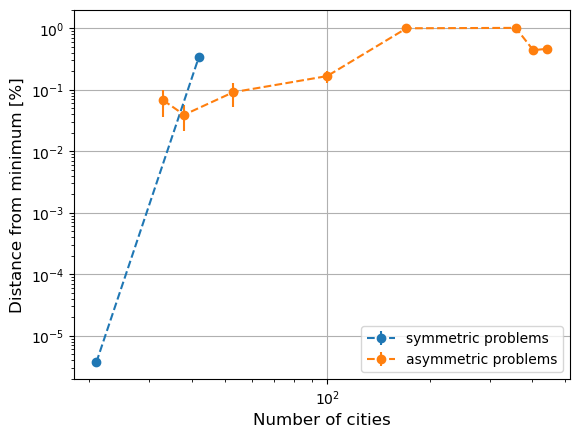

In [14]:
fig,ax = plt.subplots()

ax.errorbar(sym_ncities, sym_data, sym_errs, fmt='o--', label='symmetric problems')
ax.errorbar(asym_ncities, asym_data, asym_errs, fmt='o--', label='asymmetric problems')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of cities', fontsize=12)
ax.set_ylabel('Distance from minimum [%]', fontsize=12)
ax.grid()
ax.legend()

plt.savefig('output_images/finale.png')
plt.show()

# **Grafici per visualizzazione percorso**

In [65]:
from matplotlib.patches import FancyArrowPatch

def plot_tsp_path(coordinates, path):
    """
    Plotta il percorso del Traveling Salesman Problem.
    """
    # Crea figura
    fig, ax = plt.subplots(figsize=(6,6))
    
    # Estrai le coordinate nel giusto ordine
    x_coords = coordinates[0, path]
    y_coords = coordinates[1, path]
    
    # Aggiungi il ritorno alla città di partenza
    x_coords = np.append(x_coords, x_coords[0])
    y_coords = np.append(y_coords, y_coords[0])
    
    # Disegna il percorso
    for i in range(len(x_coords) - 1):
        color = 'C2'
        ax.plot([x_coords[i], x_coords[i+1]], 
                [y_coords[i], y_coords[i+1]], 
                color=color, linewidth=3, alpha=0.8, zorder=1,
                solid_capstyle='round')
        
        # Aggiungi frecce direzionali
        arrow = FancyArrowPatch((x_coords[i], y_coords[i]),
                               (x_coords[i+1], y_coords[i+1]),
                               arrowstyle='->', mutation_scale=25, 
                               linewidth=2, color=color, alpha=0.7, zorder=2)
        ax.add_patch(arrow)
    
    # Disegna le città
    for i, idx in enumerate(path):
        x, y = coordinates[0, idx], coordinates[1, idx]
        ax.scatter(x, y, s=250, c='#e74c3c', marker='o', 
                    edgecolors='darkred', linewidths=2.5, zorder=3, alpha=0.9)
    
    # Calcola distanza totale
    total_distance = 0
    for i in range(len(path)):
        idx1 = path[i]
        idx2 = path[(i+1) % len(path)]
        dist = np.sqrt((coordinates[0, idx1] - coordinates[0, idx2])**2 + 
                       (coordinates[1, idx1] - coordinates[1, idx2])**2)
        total_distance += dist
    
    # Info box
    info_text = f'Distanza totale: {total_distance:.2f}'
    ax.text(0.5, 0.98, info_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
           fontweight='bold')
    
    return fig, ax

## **Problema simmetrico**

In [ ]:

seed = [246, 897, 531, 343, 969, 867, 721, 555]
ncities = 15
lattice_side = 1000

cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)

nsteps              = 200000
paths               = np.zeros((ncities,nsteps))
lengths             = np.zeros(nsteps)
length_variations   = np.zeros(nsteps)
acceptances         = np.zeros(nsteps)
used_protocols      = np.zeros(nsteps)
T0 = 2000
Tf = 0.01
temperatures_raw = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/5, 2) + Tf
temperatures = np.asarray(temperatures_raw, dtype=np.float64, order='F')   # a scanso di equivoci

# Run
(paths, lengths, length_variations, acceptances, 
    total_acceptance_rate, stepwise_acceptance_rate, 
    used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
    cities_coords, cities_index, 
    distance_matrix, temperatures
)

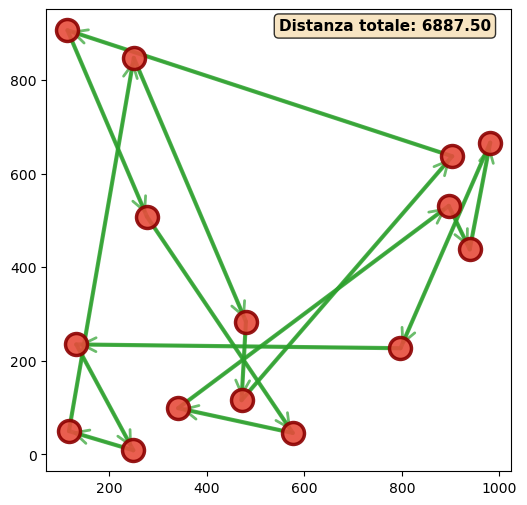

In [66]:
fig,ax = plot_tsp_path(cities_coords, paths[:,0])
plt.savefig('output_images/provaSimm1.png')

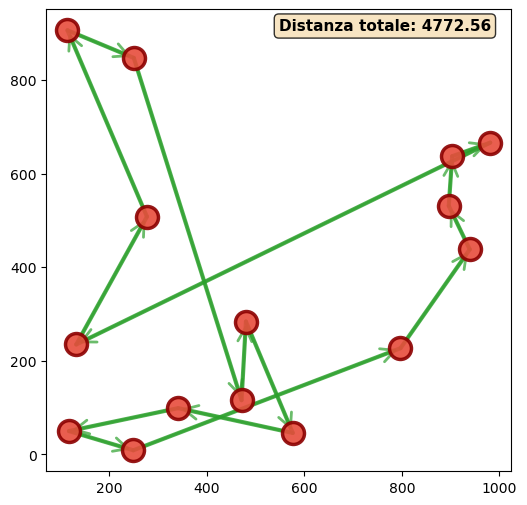

In [69]:
fig,ax = plot_tsp_path(cities_coords, paths[:,90000])
plt.savefig('output_images/provaSimm2.png')

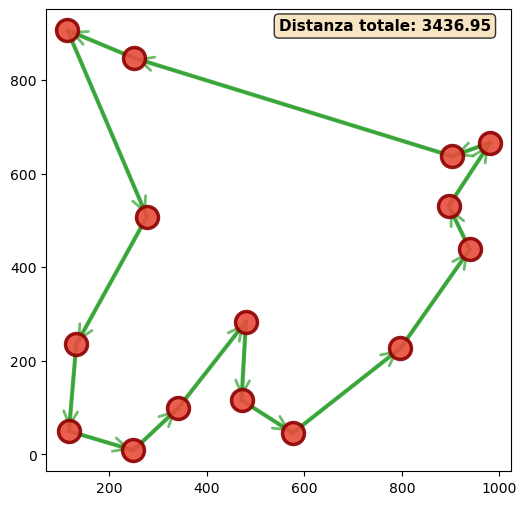

In [70]:
fig,ax = plot_tsp_path(cities_coords, paths[:,199999])
plt.savefig('output_images/provaSimm3.png')

## **Problema asimmetrico**

In [73]:
def create_penalty_matrix(coordinates, river_func, penalty):
    """
    Crea una matrice di penalità per attraversamenti del fiume. La funzione deve essere polinomiale.
    """
    N = coordinates.shape[1]
    penalty_matrix = np.zeros((N, N))
    
    # Determina per ogni città se sta sopra o sotto il fiume
    river_side = np.zeros(N, dtype=int)
    for i in range(N):
        x_i = coordinates[0, i]
        y_i = coordinates[1, i]
        # 1 se sopra il fiume, 0 se sotto
        river_side[i] = 1 if y_i > river_func(x_i) else 0
    
    # Costruisci la matrice di penalità
    for i in range(N):
        for j in range(i+1, N):
            # Se le città sono su lati opposti del fiume
            if river_side[i] != river_side[j]:
                penalty_matrix[i, j] = penalty
                penalty_matrix[j, i] = penalty  # Simmetria
    
    return penalty_matrix

In [87]:
def myfunc(x):
    a = -0.000001
    b = 0.0015
    d = 325
    x0 = 500
    y = a*(x-x0)**3 + b*(x-x0)**2 + d
    return y

### **Con penalità**

In [106]:

seed = [246, 897, 531, 343, 969, 867, 721, 555]
ncities = 15
lattice_side = 1000

cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)

nsteps              = 200000
paths               = np.zeros((ncities,nsteps))
lengths             = np.zeros(nsteps)
length_variations   = np.zeros(nsteps)
acceptances         = np.zeros(nsteps)
used_protocols      = np.zeros(nsteps)
T0 = 2000
Tf = 0.01
temperatures_raw = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/5, 2) + Tf
temperatures = np.asarray(temperatures_raw, dtype=np.float64, order='F')   # a scanso di equivoci

# Aggiunge penalità
penalty_matrix = create_penalty_matrix(cities_coords, myfunc, penalty=100)
distance_matrix += penalty_matrix

# Run
(paths, lengths, length_variations, acceptances, 
    total_acceptance_rate, stepwise_acceptance_rate, 
    used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
    cities_coords, cities_index, 
    distance_matrix, temperatures
)



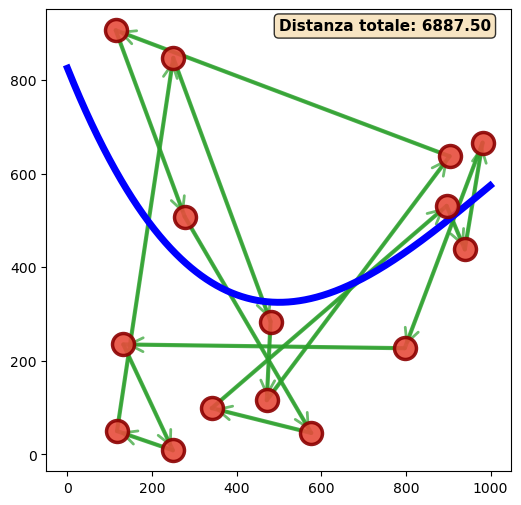

In [109]:
fig,ax = plot_tsp_path(cities_coords, paths[:,0])

xvec = np.arange(1000)
ax.plot(xvec, myfunc(xvec), color='blue', lw=5)

plt.savefig('output_images/provaAsimm1.png')

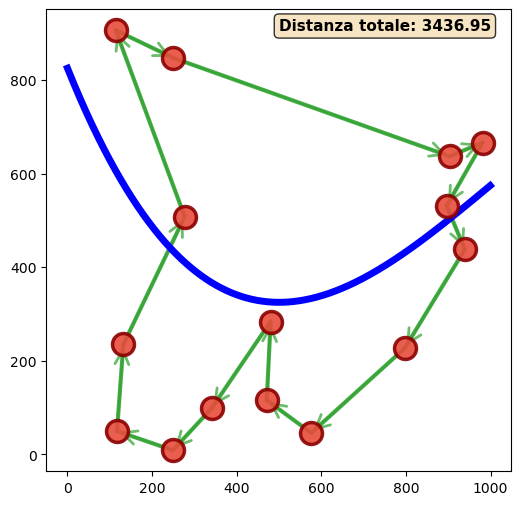

In [110]:
fig,ax = plot_tsp_path(cities_coords, paths[:,199999])

xvec = np.arange(1000)
ax.plot(xvec, myfunc(xvec), color='blue', lw=5)

plt.savefig('output_images/provaAsimm2.png')

### **Con vantaggio**

In [111]:

seed = [246, 897, 531, 343, 969, 867, 721, 555]
ncities = 15
lattice_side = 1000

cities_index, cities_coords, distance_matrix = f90.create_city_array(ncities, lattice_side, seed)

nsteps              = 200000
paths               = np.zeros((ncities,nsteps))
lengths             = np.zeros(nsteps)
length_variations   = np.zeros(nsteps)
acceptances         = np.zeros(nsteps)
used_protocols      = np.zeros(nsteps)
T0 = 2000
Tf = 0.01
temperatures_raw = T0*custom_gaussian(np.arange(1,nsteps+1), 0, nsteps/5, 2) + Tf
temperatures = np.asarray(temperatures_raw, dtype=np.float64, order='F')   # a scanso di equivoci

# Aggiunge penalità
penalty_matrix = create_penalty_matrix(cities_coords, myfunc, penalty=-100)
distance_matrix += penalty_matrix

# Run
(paths, lengths, length_variations, acceptances, 
    total_acceptance_rate, stepwise_acceptance_rate, 
    used_protocols, protocols_rate, accepted_protocols_rate) = f90.metropolis_run(
    cities_coords, cities_index, 
    distance_matrix, temperatures
)



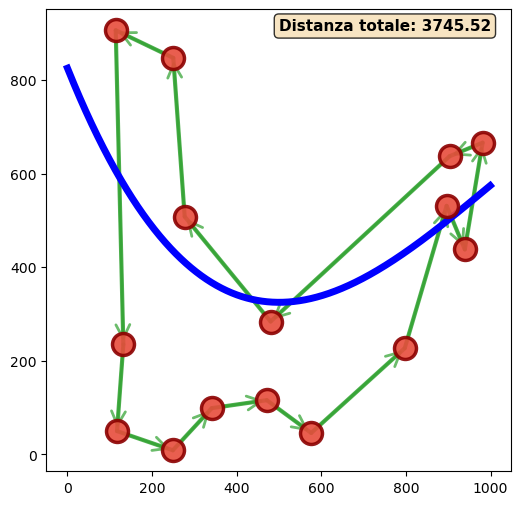

In [112]:
fig,ax = plot_tsp_path(cities_coords, paths[:,199999])

xvec = np.arange(1000)
ax.plot(xvec, myfunc(xvec), color='blue', lw=5)
plt.savefig('output_images/provaAsimm3.png')